In [63]:
# %%
# %%
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data (assuming you've stripped the header)
path_typhoon = 'D:\\InProbation\\Metocean\\Data\\Typhoon_wind\\Reanalyzed_HYB_TC_Wind_Data\\'
data = np.loadtxt(path_typhoon + "9612_KIRK_WIND.dat") 
data.shape


(607274, 901)

In [67]:
# %%
# %%
# %%
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

time_to_plot = pd.to_datetime('1996-08-12 06:00:00')
time_occur = pd.to_datetime(['1996-08-04 18:00:00', '1996-08-18 18:00:00'])
time_step = int((time_occur[1] - time_occur[0])/pd.Timedelta(hours=1) + 1)
print(f'Time step {time_step:0f}')
time_plot_idx = int((time_to_plot - time_occur[0])/pd.Timedelta(hours=1))
time_plot_idx
print(time_occur[0] + pd.Timedelta(hours=180))


Time step 337.000000
1996-08-12 06:00:00


In [68]:

wind_grid = np.reshape(data, (-1,2,901, 901))
wind_grid.shape



(337, 2, 901, 901)

In [69]:
u_comp = wind_grid[time_plot_idx,0,:,:]
v_comp = wind_grid[time_plot_idx,1,:,:]
u_comp.shape


(901, 901)

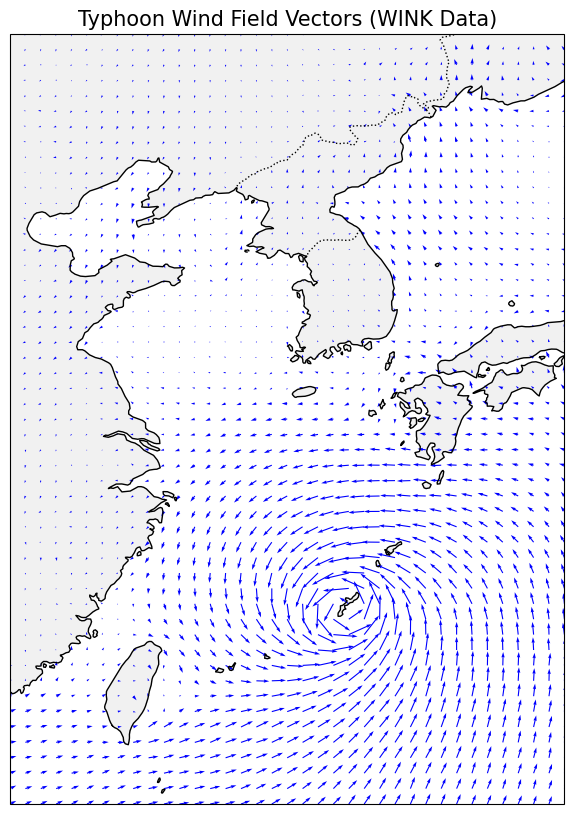

In [72]:
lon_start, lat_start = 117.0, 20.0
res = 0.03333333
size = 901

# 2. Generate Coordinates
lons = lon_start + np.arange(size) * res
lats = lat_start + np.arange(size) * res
lon_2d, lat_2d = np.meshgrid(lons, lats)

# 3. Load and Reshape your Data
# Replace 'u_file.dat' with your actual filenames
# We assume the valid "smooth" data structure we identified

# 4. Plotting with Cartopy
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add Geography for the Korean Peninsula context
ax.set_extent([117, 135, 20, 45], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

# 5. The Quiver Command
# 'skip' is critical so arrows don't overlap
skip = 15

q = ax.quiver(lon_2d[::skip, ::skip], 
              lat_2d[::skip, ::skip], 
              u_comp[::skip, ::skip], 
              v_comp[::skip, ::skip],
              color='blue', 
              scale=700,        # Adjust for arrow length
              width=0.002,      # Adjust for arrow thickness
              transform=ccrs.PlateCarree())

# Add a reference arrow (Key)
ax.quiverkey(q, 0.9, 0.05, 20, r'$20 \frac{m}{s}$', labelpos='E', coordinates='figure')

plt.title('Typhoon Wind Field Vectors (WINK Data)', fontsize=15)
plt.show()

Try out JMA-MSM sample data


In [82]:
import xarray as xr

dir_typhoon_data = 'D:\\InProbation\\Metocean\\Data\\Typhoon_wind\\'
ds = xr.open_dataset(dir_typhoon_data + "JMA_MSM_SampleData\\mesmodel_171205\\Z__C_RJTD_20171205000000_MSM_GPV_Rjp_L-pall_FH00-15_grib2.bin", engine="cfgrib")
print(ds)

skipping variable: paramId==157 shortName='r'
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\cfgrib\dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "c:\Users\User\anaconda3\envs\metocean\Lib\site-packages\cfgrib\dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  700.,  600.,
        500.,  400.,  300.,  250.,  200.,  150.,  100.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  700.,  600.,
        500.,  400.,  300.]))


<xarray.Dataset> Size: 117MB
Dimensions:        (step: 6, isobaricInhPa: 16, latitude: 253, longitude: 241)
Coordinates:
  * step           (step) timedelta64[ns] 48B 00:00:00 03:00:00 ... 15:00:00
  * isobaricInhPa  (isobaricInhPa) float64 128B 1e+03 975.0 ... 150.0 100.0
  * latitude       (latitude) float64 2kB 47.6 47.5 47.4 47.3 ... 22.6 22.5 22.4
  * longitude      (longitude) float64 2kB 120.0 120.1 120.2 ... 149.9 150.0
    time           datetime64[ns] 8B ...
    valid_time     (step) datetime64[ns] 48B ...
Data variables:
    gh             (step, isobaricInhPa, latitude, longitude) float32 23MB ...
    u              (step, isobaricInhPa, latitude, longitude) float32 23MB ...
    v              (step, isobaricInhPa, latitude, longitude) float32 23MB ...
    t              (step, isobaricInhPa, latitude, longitude) float32 23MB ...
    w              (step, isobaricInhPa, latitude, longitude) float32 23MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:        

In [88]:
ds.u.latitude


<xarray.DataArray 'latitude' (latitude: 253)> Size: 2kB
array([47.6, 47.5, 47.4, ..., 22.6, 22.5, 22.4], shape=(253,))
Coordinates:
  * latitude  (latitude) float64 2kB 47.6 47.5 47.4 47.3 ... 22.7 22.6 22.5 22.4
    time      datetime64[ns] 8B ...
Attributes:
    units:             degrees_north
    standard_name:     latitude
    long_name:         latitude
    stored_direction:  decreasing